In [1]:
import os
from google.colab import userdata

# Kaggle Authentication
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Dataset Download
!pip install kaggle>=1.8.0 -q
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/brain-tumor/

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:07<00:00, 20.8MB/s]



In [2]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from collections import Counter
import random
import time
import os
import copy

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}')
print(f'Seed fixed at: {SEED}')

Using cuda
Seed fixed at: 42


## Dataset

**Brain Tumor MRI Dataset** (Masoud Nickparvar, Kaggle) — 7,023 contrast-enhanced
T1-weighted axial MRI scans across four classes: **glioma**, **meningioma**,
**no tumour**, and **pituitary tumour**. The data ships pre-split into Training
(5,712 images) and Testing (1,311 images) folders.

We chose this dataset because (i) it is a well-defined multi-class medical
imaging task that benefits from ImageNet-pretrained backbones (a recognised
research question), (ii) misclassification has real clinical consequences,
making per-class error analysis meaningful, and (iii) the relatively small
training set lets us study data scarcity within a Colab budget.

All images are resized to 224×224 to match the ResNet50 receptive field.
Training images use mild augmentation (horizontal flip, ±15° rotation, small
brightness/contrast jitter); test images are not augmented. Normalisation uses
ImageNet statistics so the pretrained ResNet50 weights remain meaningful.

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )])

# Labels for the folder names are glioma=0, meningioma=1, notumor=2, pituitary=3
TRAIN_PATH = '/content/brain-tumor/Training'
TEST_PATH  = '/content/brain-tumor/Testing'

train_dataset = torchvision.datasets.ImageFolder(
    root=TRAIN_PATH,
    transform=train_transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root=TEST_PATH,
    transform=test_transform
)

CLASS_NAMES = train_dataset.classes
print(f"Classes found: {CLASS_NAMES}")
print(f"Training images: {len(train_dataset):,}")
print(f"Testing images: {len(test_dataset):,}")

train_counts = Counter(train_dataset.targets)
test_counts  = Counter(test_dataset.targets)
print("Train class counts:",
      {CLASS_NAMES[k]: v for k, v in sorted(train_counts.items())})
print("Test  class counts:",
      {CLASS_NAMES[k]: v for k, v in sorted(test_counts.items())})

train_loader = DataLoader(train_dataset,
                          batch_size = BATCH_SIZE,
                          shuffle = True,
                          num_workers = 2,
                          pin_memory = True)

test_loader = DataLoader(test_dataset,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 2,
                         pin_memory = True)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches:  {len(test_loader)}")

Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 5,600
Testing images: 1,600
Training batches: 175
Testing batches:  50


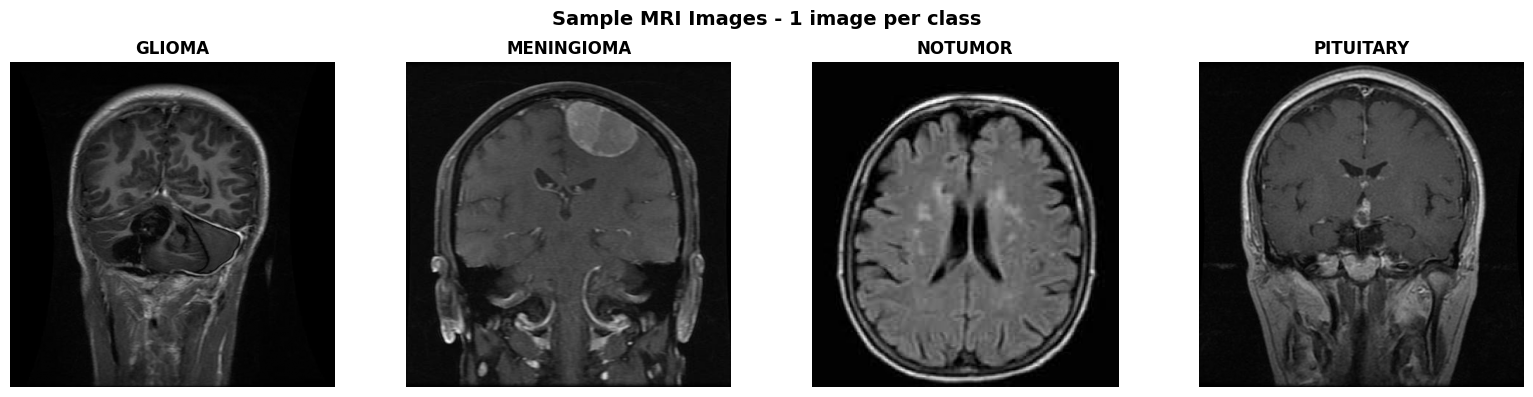

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample MRI Images - 1 image per class',fontsize=14,fontweight='bold')
for idx, class_name in enumerate(CLASS_NAMES):

    class_path = Path(TRAIN_PATH) / class_name
    img_path = list(class_path.glob('*.jpg'))[0]

    img = plt.imread(str(img_path))
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{class_name.upper()}',fontweight='bold',fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png',dpi=150, bbox_inches='tight')
plt.show()

## CNN






In [6]:
class CNN_model(nn.Module):
    def __init__(self, num_classes=4):
        super(CNN_model, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3,padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

cnn_model = CNN_model(num_classes=4).to(device)
total_params = sum(p.numel()
                   for p in cnn_model.parameters()
                   if p.requires_grad)

print(f"Total parameters: {total_params:,}")

Total parameters: 422,564


## ResNet50 Pretrained (transfer learning)

Used two strategies here: **frozen**, which locks all the pretrained layers and trains only the final layer; and **fine-tuned**, which unlocks all layers and trains the entire network.

In [7]:
def build_resnet50(strategy='finetune', num_classes=4):

    model = models.resnet50(weights='IMAGENET1K_V1')

    if strategy == 'frozen':
        for param in model.parameters():
            param.requires_grad = False
        print("Frozen")

    elif strategy == 'finetune':
        for param in model.parameters():
            param.requires_grad = True
        print("Fine-tuned")

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )

    return model.to(device)

resnet_frozen = build_resnet50(strategy='frozen')
frozen_params = sum(p.numel() for p in resnet_frozen.parameters()
                    if p.requires_grad)
print(f"Parameters: {frozen_params:,}")

resnet_finetune = build_resnet50(strategy='finetune')
finetune_params = sum(p.numel() for p in resnet_finetune.parameters()
                      if p.requires_grad)
print(f"Parameters: {finetune_params:,}")

Frozen
Parameters: 526,084
Fine-tuned
Parameters: 24,034,116


In [8]:
def train_model(model, train_loader, test_loader,
                num_epochs=20, lr=0.0001,
                model_name='Model',
                save_path=None):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3,
    )

    batch_losses = []
    train_accuracy = []
    test_accuracy = []
    test_losses = []
    best_accuracy = 0.0
    best_state = None

    print(f"Training: {model_name}")
    print(f"Epochs: {num_epochs}  LR: {lr}")

    for epoch in range(num_epochs):
        start_time = time.time()

        model.train()
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.detach().item())

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = 100 * correct_train / total_train
        train_accuracy.append(train_acc)

        model.eval()
        correct_test = 0
        total_test = 0
        test_loss_sum = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct_test += (predicted == labels).sum().item()
                total_test += labels.size(0)

        test_acc = 100 * correct_test / total_test
        test_loss = test_loss_sum / total_test
        test_accuracy.append(test_acc)
        test_losses.append(test_loss)

        scheduler.step(test_acc)

        new_best = test_acc > best_accuracy

        if new_best:
            best_accuracy = test_acc
            best_state = copy.deepcopy(model.state_dict())

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1:>2}/{num_epochs}  "
              f"Loss: {batch_losses[-1]:.4f}  "
              f"TestLoss: {test_loss:.4f} "
              f"Train: {train_acc:.2f}% "
              f"Test: {test_acc:.2f}%  "
              f"Time: {epoch_time:.1f}s  "
              f"{'new best' if new_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
        if save_path is not None:
            torch.save(best_state, save_path)
            print(f"Best weights saved to {save_path}")

    print(f"Best Test Accuracy: {best_accuracy:.2f}%")

    return batch_losses, train_accuracy, test_accuracy,test_losses, best_accuracy

# Experiment 1
#### What this experiment does answer the question:
##### "Does transfer learning from ImageNet help classify brain tumours better than learning from scratch?"
We train two models:\
CNN from Scratch — no prior knowledge\
ResNet50 Fine-tuned — pretrained on ImageNet




In [9]:
print("Experiment 1: CNN vs ResNet50 Fine-tuned")

cnn_model = CNN_model(num_classes=4).to(device)

cnn_losses, cnn_train_accs, cnn_test_accs, cnn_test_losses, cnn_best = train_model(
    cnn_model,
    train_loader,
    test_loader,
    num_epochs = 20,
    lr = 0.001,
    model_name = 'CNN from Scratch',
    save_path  = 'CNN_best.pth')

resnet_finetune = build_resnet50(strategy='finetune')

res_losses, res_train_accs, res_test_accs, res_test_losses, res_best = train_model(
    resnet_finetune,
    train_loader,
    test_loader,
    num_epochs = 20,
    lr = 0.0001,
    model_name = 'ResNet50 Fine-tuned',
    save_path  = 'ResNet50_finetuned_best.pth')

print("Experiment 1 Results")
print(f"CNN:{cnn_best:.2f}%")
print(f"ResNet50 Fine-tuned:{res_best:.2f}%")
print(f"Improvement:{res_best - cnn_best:.2f}%")

Experiment 1: CNN vs ResNet50 Fine-tuned
Training: CNN from Scratch
Epochs: 20  LR: 0.001
Epoch  1/20  Loss: 1.2153  Train: 67.84% Test: 54.19%  Time: 21.2s  new best
Epoch  2/20  Loss: 0.4886  Train: 76.48% Test: 61.88%  Time: 19.8s  new best
Epoch  3/20  Loss: 0.3232  Train: 80.05% Test: 52.31%  Time: 20.2s  
Epoch  4/20  Loss: 0.5513  Train: 82.02% Test: 67.25%  Time: 20.1s  new best
Epoch  5/20  Loss: 0.3449  Train: 83.64% Test: 63.19%  Time: 20.1s  
Epoch  6/20  Loss: 0.7806  Train: 84.68% Test: 55.75%  Time: 19.9s  
Epoch  7/20  Loss: 0.2394  Train: 85.57% Test: 63.12%  Time: 20.4s  
Epoch  8/20  Loss: 0.5853  Train: 86.48% Test: 72.38%  Time: 20.4s  new best
Epoch  9/20  Loss: 0.5695  Train: 87.41% Test: 54.12%  Time: 20.2s  
Epoch 10/20  Loss: 0.2042  Train: 87.27% Test: 71.56%  Time: 20.0s  
Epoch 11/20  Loss: 0.1794  Train: 87.70% Test: 73.12%  Time: 19.9s  new best
Epoch 12/20  Loss: 0.2482  Train: 88.38% Test: 81.62%  Time: 20.0s  new best
Epoch 13/20  Loss: 0.1780  Train: 

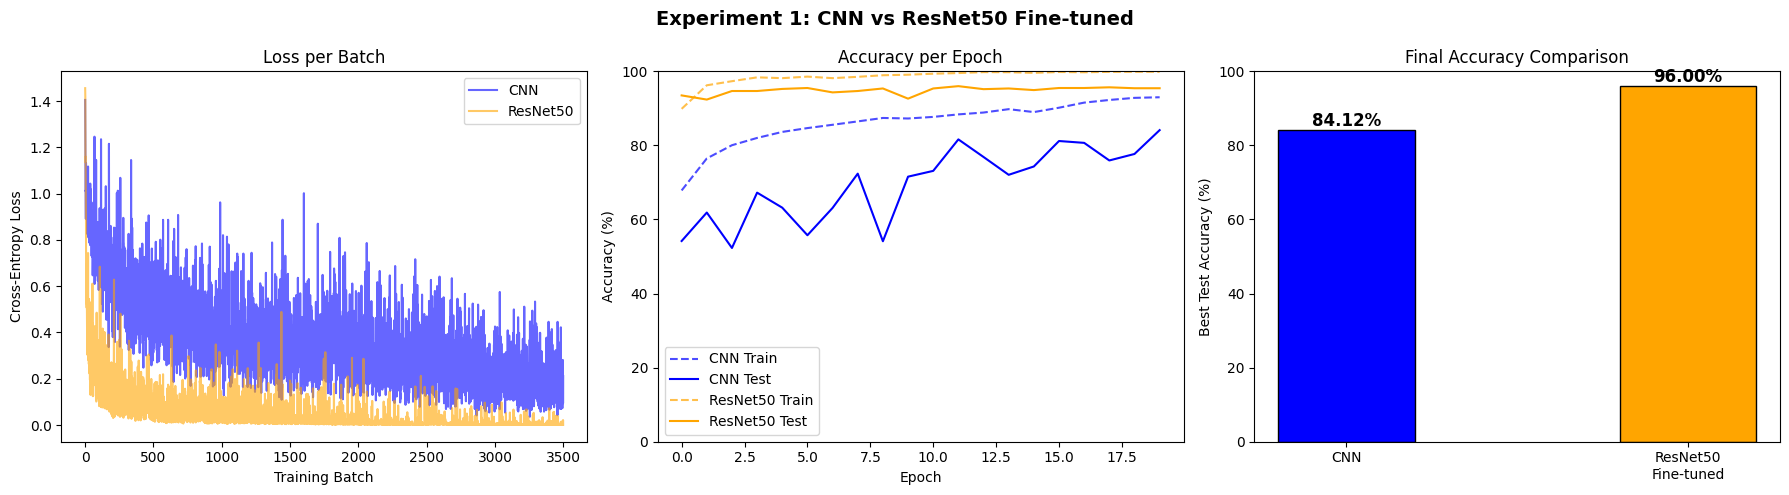

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Experiment 1: CNN vs ResNet50 Fine-tuned',fontsize=14, fontweight='bold')

# Plot 1 Loss per batch
axes[0].plot(cnn_losses,
             alpha=0.6,
             label='CNN',
             color='blue')
axes[0].plot(res_losses,
             alpha=0.6,
             label='ResNet50',
             color='orange')
axes[0].set_xlabel('Training Batch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss per Batch')
axes[0].legend()

# Plot 2 Accuracy per epoch
axes[1].plot(cnn_train_accs,
             label='CNN Train',
             color='blue',
             linestyle='--',
             alpha=0.7)
axes[1].plot(cnn_test_accs,
             label='CNN Test',
             color='blue')
axes[1].plot(res_train_accs,
             label='ResNet50 Train',
             color='orange',
             linestyle='--',
             alpha=0.7)
axes[1].plot(res_test_accs,
             label='ResNet50 Test',
             color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per Epoch')
axes[1].legend()
axes[1].set_ylim(0, 100)

# Plot 3 Test loss per epoch
axes[2].plot(cnn_test_losses,
             label='CNN',
             color='blue',
             linewidth=2,
             marker='o',
             markersize=4)
axes[2].plot(res_test_losses,
             label='ResNet50',
             color='orange',
             linewidth=2,
             marker='s',
             markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Test Cross-Entropy Loss')
axes[2].set_title('Test Loss per Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4 Accuracy comparison
model_names = ['CNN', 'ResNet50\nFine-tuned']
best_accs   = [cnn_best, res_best]
colors      = ['blue', 'orange']
bars = axes[2].bar(model_names, best_accs,
                   color=colors,
                   edgecolor='black',
                   width=0.4)
axes[2].set_ylabel('Best Test Accuracy (%)')
axes[2].set_title('Final Accuracy Comparison')
axes[2].set_ylim(0, 100)

for bar, acc in zip(bars, best_accs):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{acc:.2f}%',
        ha='center',
        fontweight='bold',
        fontsize=12)

plt.tight_layout()
plt.savefig('experiment1_results.png',dpi=150, bbox_inches='tight')
plt.show()

# Experiment 2
#### Question: "Is it better to freeze ResNet50 layers or fine-tune the entire network?"


In [11]:
print("Experiment 2: Frozen vs Fine-tuned ResNet50")

resnet_frozen = build_resnet50(strategy='frozen')

frz_losses, frz_train_accs, frz_test_accs, frz_test_losses, frz_best = train_model(
    resnet_frozen,
    train_loader,
    test_loader,
    num_epochs=20,
    lr=0.001,
    model_name='ResNet50 Frozen',
    save_path='ResNet50_frozen_best.pth')

print("Experiment 2 result")
print(f"ResNet50 Frozen: {frz_best:.2f}%")
print(f"ResNet50 Fine-tuned: {res_best:.2f}%")
print(f"Fine-tuning gain: {res_best - frz_best:.2f}%")

Experiment 2: Frozen vs Fine-tuned ResNet50
Frozen
Training: ResNet50 Frozen
Epochs: 20  LR: 0.001
Epoch  1/20  Loss: 0.3816  Train: 83.27% Test: 77.62%  Time: 20.7s  new best
Epoch  2/20  Loss: 0.1666  Train: 87.43% Test: 83.75%  Time: 20.5s  new best
Epoch  3/20  Loss: 0.3957  Train: 89.11% Test: 84.69%  Time: 20.1s  new best
Epoch  4/20  Loss: 0.3542  Train: 89.73% Test: 85.62%  Time: 20.2s  new best
Epoch  5/20  Loss: 0.4285  Train: 90.36% Test: 85.00%  Time: 20.6s  
Epoch  6/20  Loss: 0.4803  Train: 90.70% Test: 87.31%  Time: 20.2s  new best
Epoch  7/20  Loss: 0.2491  Train: 90.71% Test: 87.38%  Time: 20.2s  new best
Epoch  8/20  Loss: 0.1855  Train: 91.71% Test: 85.56%  Time: 20.5s  
Epoch  9/20  Loss: 0.1678  Train: 91.70% Test: 85.94%  Time: 20.6s  
Epoch 10/20  Loss: 0.2781  Train: 91.79% Test: 88.56%  Time: 20.7s  new best
Epoch 11/20  Loss: 0.3524  Train: 91.80% Test: 87.06%  Time: 20.6s  
Epoch 12/20  Loss: 0.1337  Train: 92.14% Test: 88.00%  Time: 20.4s  
Epoch 13/20  Loss

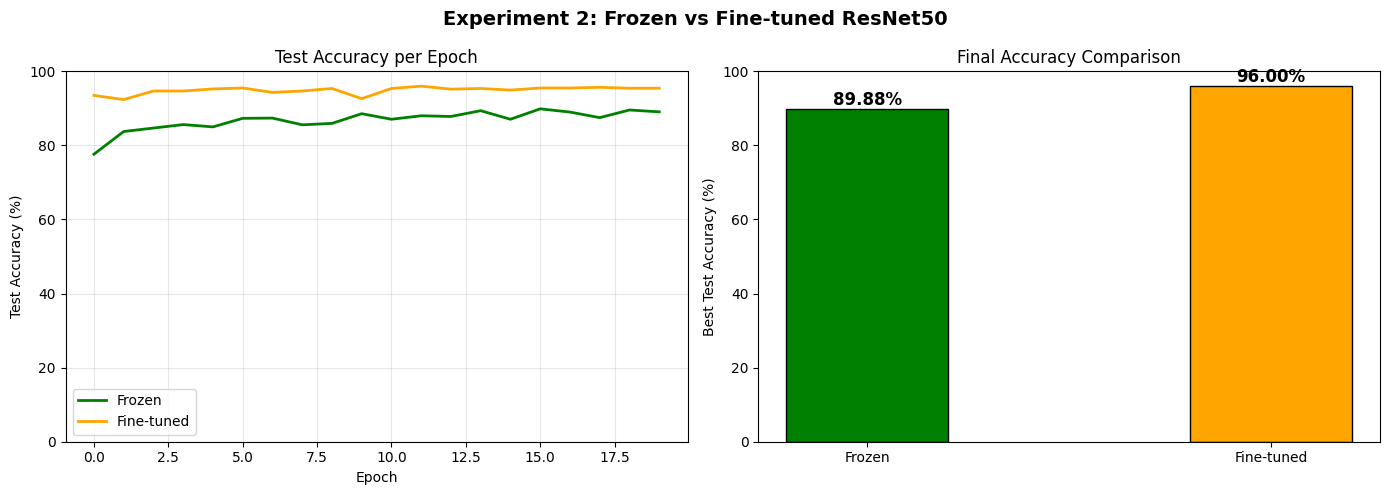

In [12]:
fig,axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 2: Frozen vs Fine-tuned ResNet50',fontsize=14, fontweight='bold')

# PLOT 1 Accuracy per epoch
axes[0].plot(frz_test_accs, label='Frozen',
             color='green', linewidth=2)
axes[0].plot(res_test_accs, label='Fine-tuned',
             color='orange', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy per Epoch')
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# PLOT 2 Bar chart
model_names = ['Frozen', 'Fine-tuned']
best_accs   = [frz_best, res_best]
colors      = ['green', 'orange']
bars = axes[1].bar(model_names, best_accs,
                   color=colors,
                   edgecolor='black',
                   width=0.4)
axes[1].set_ylabel('Best Test Accuracy (%)')
axes[1].set_title('Final Accuracy Comparison')
axes[1].set_ylim(0, 100)
for bar, acc in zip(bars, best_accs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{acc:.2f}%',
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.tight_layout()
plt.savefig('experiment2_results.png',dpi = 150, bbox_inches = 'tight')
plt.show()

# Experiment 3
#### Question: "How does limited training data affect CNN vs ResNet50?"



In [13]:
print("Experiment 3: Data Scarcity Study")
fractions   = [0.25, 0.50, 0.75, 1.0]
cnn_results = []
res_results = []

for frac in fractions:
    n = int(len(train_dataset) * frac)
    remainder = len(train_dataset) - n

    subset, _ = random_split(
        train_dataset,
        [n, remainder],
        generator=torch.Generator().manual_seed(SEED)
    )

    subset_loader = DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )
    cnn_save = f'CNN_data{int(frac*100)}.pth' if frac == 1.0 else None
    res_save = f'ResNet50_data{int(frac*100)}.pth' if frac == 1.0 else None

    print(f"Using {int(frac*100)}% of data = {n} images")

    m1 = CNN_model(num_classes=4).to(device)
    _, _, _, _,best_cnn = train_model(
        m1,
        subset_loader,
        test_loader,
        num_epochs=15,
        lr=0.001,
        model_name=f'CNN {int(frac*100)}%'
    )
    cnn_results.append(best_cnn)

    m2 = build_resnet50(strategy='finetune')
    _, _, _, best_res = train_model(
        m2,
        subset_loader,
        test_loader,
        num_epochs=15,
        lr=0.0001,
        model_name=f'ResNet50 {int(frac*100)}%'
    )
    res_results.append(best_res)

print("Experiment 3 Results")
print(f"{'Data %':<10} {'CNN Scratch':>12} {'ResNet50':>12}")
for frac, cnn_acc, res_acc in zip(fractions, cnn_results, res_results):
    print(f"{int(frac*100)}%{'':<7}"
          f"{cnn_acc:>11.2f}%"
          f"{res_acc:>11.2f}%")

Experiment 3: Data Scarcity Study
Using 25% of data = 1400 images
Training: CNN 25%
Epochs: 15  LR: 0.001
Epoch  1/15  Loss: 0.9258  Train: 61.50% Test: 56.06%  Time: 7.9s  new best
Epoch  2/15  Loss: 0.6391  Train: 69.07% Test: 47.94%  Time: 7.8s  
Epoch  3/15  Loss: 0.9549  Train: 70.00% Test: 62.19%  Time: 7.8s  new best
Epoch  4/15  Loss: 0.6979  Train: 71.43% Test: 51.94%  Time: 7.8s  
Epoch  5/15  Loss: 0.5684  Train: 72.14% Test: 67.94%  Time: 7.8s  new best
Epoch  6/15  Loss: 0.7354  Train: 79.21% Test: 43.50%  Time: 7.7s  
Epoch  7/15  Loss: 0.4870  Train: 76.93% Test: 64.44%  Time: 7.8s  
Epoch  8/15  Loss: 0.3225  Train: 78.64% Test: 66.19%  Time: 7.8s  
Epoch  9/15  Loss: 0.6272  Train: 82.07% Test: 58.19%  Time: 7.8s  
Epoch 10/15  Loss: 0.5058  Train: 83.71% Test: 77.44%  Time: 7.7s  new best
Epoch 11/15  Loss: 0.5889  Train: 84.00% Test: 78.56%  Time: 7.8s  new best
Epoch 12/15  Loss: 0.2923  Train: 84.36% Test: 68.62%  Time: 7.8s  
Epoch 13/15  Loss: 0.6540  Train: 84.1

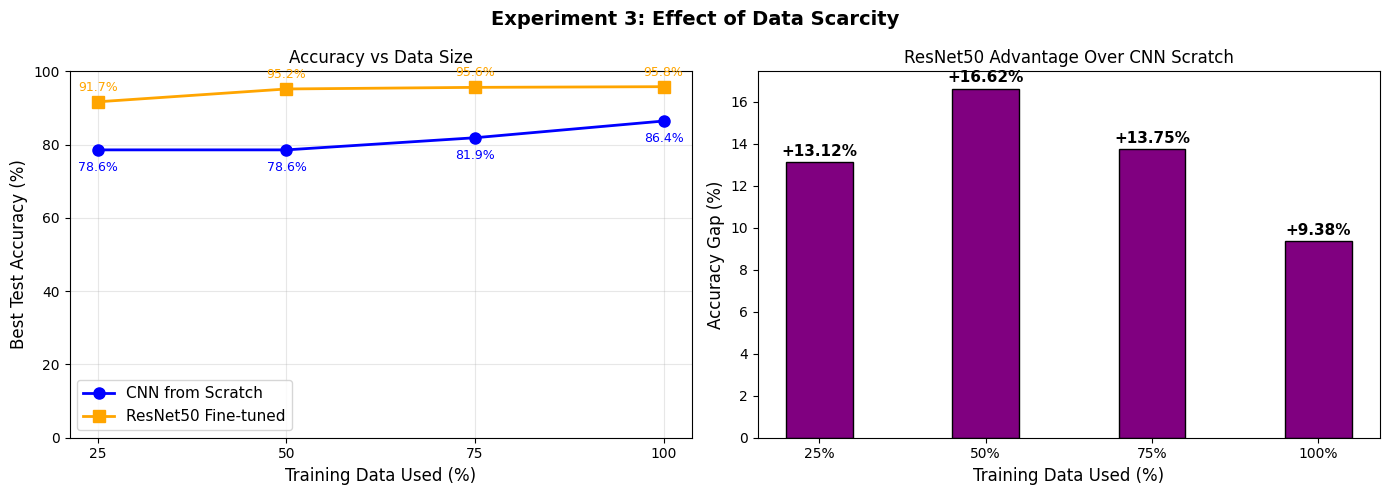

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 3: Effect of Data Scarcity',fontsize=14, fontweight='bold')

x = [25, 50, 75, 100]

# Plot 1 Accuracy vs data percentage
axes[0].plot(x,cnn_results,'o-',
             color='blue',
             label='CNN from Scratch',
             linewidth=2, markersize=8)
axes[0].plot(x,res_results,'s-',
             color='orange',
             label='ResNet50 Fine-tuned',
             linewidth=2, markersize=8)

for i, (c, r) in enumerate(
        zip(cnn_results, res_results)):
      axes[0].annotate(
        f'{c:.1f}%',
        (x[i], c),
        textcoords='offset points',
        xytext=(0, -15),
        ha='center', fontsize=9, color='blue')
      axes[0].annotate(
        f'{r:.1f}%',
        (x[i], r),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center', fontsize=9, color='orange')

axes[0].set_xlabel('Training Data Used (%)',fontsize=12)
axes[0].set_ylabel('Best Test Accuracy (%)',fontsize=12)
axes[0].set_title('Accuracy vs Data Size')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(x)
axes[0].set_ylim(0, 100)

# Plot 2 Gap between models
gaps = [r - c for r, c in zip(res_results, cnn_results)]
bars = axes[1].bar([f'{int(f*100)}%' for f in fractions],
                   gaps,
                   color='purple',
                   edgecolor='black',
                   width=0.4)
axes[1].set_xlabel('Training Data Used (%)',fontsize=12)
axes[1].set_ylabel('Accuracy Gap (%)',fontsize=12)
axes[1].set_title('ResNet50 Advantage Over CNN Scratch')
for bar, gap in zip(bars, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'+{gap:.2f}%',
                 ha='center',
                 fontweight='bold',
                 fontsize=11)

plt.tight_layout()
plt.savefig('experiment3_scarcity.png',dpi=150, bbox_inches='tight')
plt.show()

# Experiment 4
#### Question: "Which tumour type is hardest to classify and why?"


Experiment 4: Error Analysis


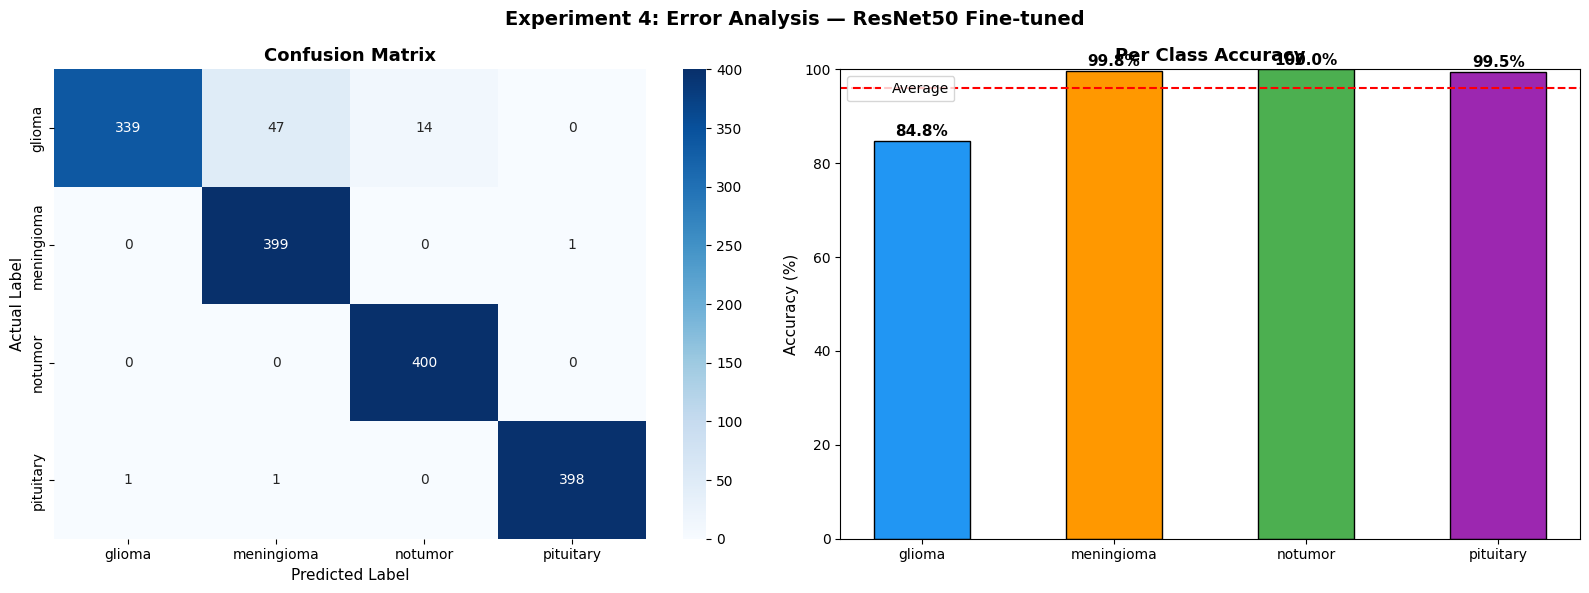

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.85      0.92       400
  meningioma       0.89      1.00      0.94       400
     notumor       0.97      1.00      0.98       400
   pituitary       1.00      0.99      1.00       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



In [15]:
print("Experiment 4: Error Analysis")

resnet_finetune.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = resnet_finetune(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Experiment 4: Error Analysis — ResNet50 Fine-tuned',fontsize=14, fontweight='bold')

# Plot 1  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[0],
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix',fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Plot 2  Per Class Accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
bars = axes[1].bar(CLASS_NAMES,
                   per_class_acc,
                   color=colors,
                   edgecolor='black',
                   width=0.5)

axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Per Class Accuracy',fontsize=13,fontweight='bold')
axes[1].set_ylim(0,100)
axes[1].axhline(y = sum(per_class_acc) / len(per_class_acc),
                color ='red',
                linestyle = '--',
                linewidth = 1.5,
                label = 'Average')
axes[1].legend()

for bar, acc in zip(bars, per_class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{acc:.1f}%',
                 ha = 'center',
                 fontweight = 'bold',
                 fontsize = 11)

plt.tight_layout()
plt.savefig('Experiment4_confusion.png',dpi = 150, bbox_inches = 'tight')
plt.show()

print("Detailed Classification Report:")
print(classification_report(y_true, y_pred,target_names=CLASS_NAMES))

In [16]:
print("Result Summary")

print("Experiment 1 — Transfer Learning")
print(f"CNN:{cnn_best:.2f}%")
print(f"ResNet50 Fine-tuned:{res_best:.2f}%")
print(f"Transfer learning gain:{res_best-cnn_best:.2f}%")

print("Experiment 2 — Training Strategy")
print(f"ResNet50 Frozen: {frz_best:.2f}%")
print(f"ResNet50 Fine-tuned:{res_best:.2f}%")
print(f"  Fine-tuning gain:{res_best-frz_best:.2f}%")

print("Experiment 3 — Data Scarcity")
print(f" {'Data':<8} {'CNN':>10} {'ResNet50':>10}")
for frac, c, r in zip(fractions,cnn_results,res_results):
    print(f"{int(frac*100)}%{'':<5}"
          f"{c:>9.2f}% {r:>9.2f}%")

print("Experiment 4 — Per Class Accuracy")
for name, acc in zip(CLASS_NAMES, per_class_acc):
    print(f"{name:<15} {acc:.1f}%")

all_models = {
    'CNN': cnn_best,
    'ResNet50 Frozen': frz_best,
    'ResNet50 Fine-tuned': res_best,
}
best_name, best_value = max(all_models.items(), key=lambda kv: kv[1])

Result Summary
Experiment 1 — Transfer Learning
CNN:84.12%
ResNet50 Fine-tuned:96.00%
Transfer learning gain:11.88%
Experiment 2 — Training Strategy
ResNet50 Frozen: 89.88%
ResNet50 Fine-tuned:96.00%
  Fine-tuning gain:6.12%
Experiment 3 — Data Scarcity
 Data            CNN   ResNet50
25%         78.56%     91.69%
50%         78.56%     95.19%
75%         81.88%     95.62%
100%         86.44%     95.81%
Experiment 4 — Per Class Accuracy
glioma          84.8%
meningioma      99.8%
notumor         100.0%
pituitary       99.5%
